In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "rohanbhuin"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
#else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/Midterm-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/rohanbhuin/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam


# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: March 6, 2026**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Apex Legends) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Answer:** The objective of this experiment is to determine whether the mean perceived comfort level differs among controller grips made from four different material types: plastic, rubber, silicone, and metal.

**Question 2.** Specify the outcome variable

**Answer:** The outcome variable is Comfort Level Rating, measured on a scale from 1-10 (upto one decimal place), which is a quantitative, continuous variable.

**Question 3.** Specify the independent variable. What are some possible lurking variables?

**Answer:**
- **IV:** Material types used for the controller grips. It is a nominal, categorical variable with 4 levels (plastic, rubber, silicone, and metal).
- **Possible Lurking Variables:** Hand size, grip strength, amount of controller use, hand moisture during play, personal preference, and any differences in controller shape, weight, or build quality aside from the grip material.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

**Answer:** A completely randomized design may be appropriate because there is one factor of interest, grip material type, with four treatment levels. Assuming the professional gamers are relatively homogeneous who are playing the same game and the controllers are identical except for grip material, the treatments can be randomly assigned to the gamers. With randomization and replication, a CRD allows us to assess whether differences in comfort ratings are due to grip material rather than random variation. Thus, CRD is most suitable for this experiment.

**Question 5.** State the null and alternative hypotheses for this experiment.

**Answer:**
$$ \begin{align}
H_0&: \mu_{\text{Plastic}} = \mu_{\text{Rubber}} = \mu_{\text{Silicone}} = \mu_{\text{Metal}} \\
H_1&: \text{Not all population mean comfort ratings are equal}
\end{align}
$$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Answer:**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Material  40 non-null     object 
 1   Comfort   40 non-null     float64
dtypes: float64(1), object(1)
memory usage: 772.0+ bytes
None
          mean       std
Material                
Metal     5.39  0.877433
Plastic   5.93  0.620125
Rubber    6.23  0.702456
Silicone  7.63  0.700872 



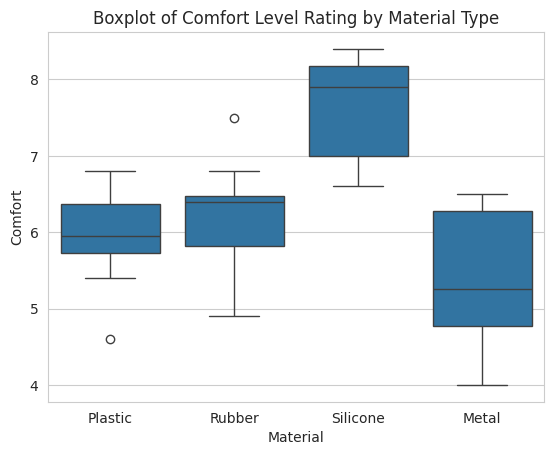

In [2]:
## Import Necessary Python Packages ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

## Read in Video Game Controllers Excel File ##
controller_data = pd.read_excel("Video Game Controllers.xlsx")

## Data Integrity Check ##
print(controller_data.info())

## Calculate Mean and Standard Deviation
## of Comfort Level Rating by Material Type ##
controller_stats = controller_data.groupby('Material')['Comfort'].agg(['mean','std'])

print(controller_stats, "\n")

## Generate Boxplot for Visual Comparison ##
## Set style (default is "darkgrid") ##
sns.set_style("whitegrid")

## Create boxplot ##
sns.boxplot(x="Material",y="Comfort",data=controller_data)

## Add Title and Labels ##
plt.title("Boxplot of Comfort Level Rating by Material Type", loc='center')
plt.xlabel("Material")
plt.ylabel("Comfort")
plt.show()

Based on the summary statistics, the mean comfort ratings are not the same across the four material types. Silicone has the highest mean rating (7.63), followed by Rubber (6.23), Plastic (5.93), and Metal (5.39). The difference between Silicone and the remaining materials appears substantial relative to the within-group standard deviations.

The boxplot supports this finding, as the Silicone distribution is centered noticeably above the others with limited overlap, while Plastic, Rubber, and Metal overlap more.

Thus, the exploratory analysis lends stronger support to the alternative hypothesis, since the treatment means appear to differ, especially for the Silicone group.

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a testing and visual method. Do the results of the normality test(s) support the assumption of normality?

**Answer:**

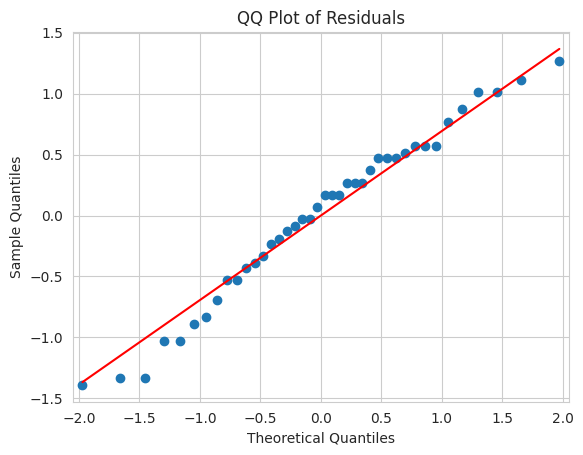

Shapiro-Wilk Test Statistic: 0.9710
Shapiro-Wilk Test P-Value: 0.3874
Fail to reject null hypothesis: Residuals are normally distributed.


In [3]:
## Checking assumption of normality using visual method ##
## Import scipy ##
import scipy.stats as stats

## Fit One Way ANOVA Model ##
controller_mod = ols("Comfort~Material",data=controller_data).fit()

## Extract Model Residuals ##
residuals = controller_mod.resid

## Generate QQ plot using seaborn ##
sm.qqplot(residuals, line ='s')
plt.title("QQ Plot of Residuals")
plt.show()

## Performing Shapiro-Wilk Test of Normality ##
sw_test = stats.shapiro(residuals)

## Extracting Test Stat and P-Value ##
sw_stat = sw_test.statistic
sw_pvalue = sw_test.pvalue

## Printing Results ##
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {sw_pvalue:.4f}")
if sw_pvalue > 0.05:
    print("Fail to reject null hypothesis: Residuals are normally distributed.")
else:
    print("Reject null hypothesis: Residuals are not normally distributed.")

From the QQ plot, the residuals appear to follow the reference line fairly closely, with only minor deviations near the ends, suggesting no serious violation of normality.

The Shapiro–Wilk test gave a statistic of ($W=0.9710$) and a p-value ($p=0.3874$). Since $p > \alpha = 0.05$, we fail to reject the null hypothesis that the residuals are normally distributed.

Therefore, the results of both the visual and formal normality checks support the assumption of normality.

**Question 8.** Test the assumption of homogeneity of variance using **both** a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Answer:**

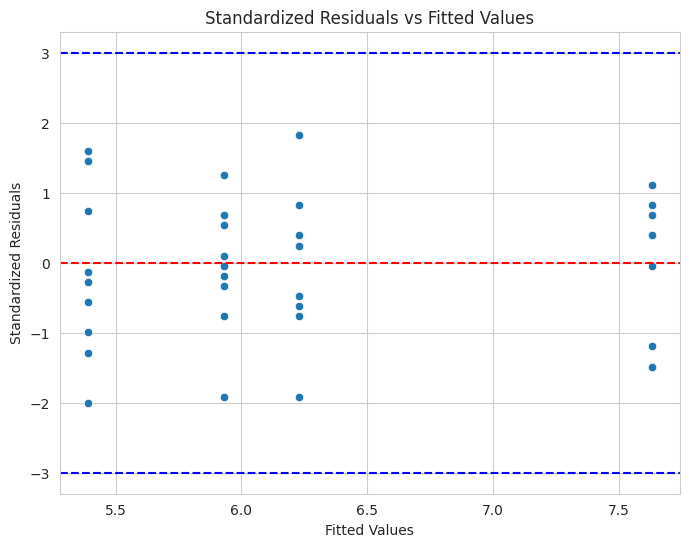

BP Test F-statistic: 0.684288131275624
BP Test F p-value: 0.5674916917969977
Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.


In [4]:
## Obtain Standardized Residuals ##
standardized_residuals = controller_mod.get_influence().resid_studentized_internal

## Get the fitted values ##
fitted_values = controller_mod.fittedvalues

## Create the plot using seaborn ##
plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## Import necessary function: ##
from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##
bp_test = het_breuschpagan(controller_mod.resid,controller_mod.model.exog)

## Extract F-statistic ##
f_statistic = bp_test[2]

## Extract its P-Value ##
f_p_value = bp_test[3]

print(f"BP Test F-statistic: {f_statistic}")
print(f"BP Test F p-value: {f_p_value}")
if f_p_value > 0.05:
    print("Fail to reject null hypothesis: Homoscedasticity detected. Constant Variance assumed.")
else:
    print("Reject null hypothesis: Heteroscedasticity detected. Constant Variance not assumed.")

From the residual plot:
- The points appear randomly scattered around 0 with a fairly similar vertical spread across fitted values.
- There is no clear pattern suggesting changing variance.
- All standardized residuals fall within the $\pm$3 reference lines.

The Breusch-Pagan test gave an F-statistic of 0.6843 and a p-value of 0.5675. Since $p > \alpha = 0.05$, we fail to reject the null hypothesis of constant variance.

Therefore, both the visual and formal methods support the assumption of homogeneity of variance.

**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?

**Answer:**

In [5]:
## Fit One-Way ANOVA Model ##
controller_mod = ols("Comfort~Material",data=controller_data).fit()

## Print ANOVA Table Adding Significance Column ##
tab = sm.stats.anova_lm(controller_mod,typ=1)

tab["Significant"] = np.where(tab["PR(>F)"]<0.05,"Yes","No")

print(tab)


            df  sum_sq   mean_sq          F        PR(>F) Significant
Material   3.0  27.387  9.129000  17.070642  4.616153e-07         Yes
Residual  36.0  19.252  0.534778        NaN           NaN          No


- Our $F_{\text{Stat}} = F(3, 36)  = 17.07$ and has an associated p-value $p < 0.001$.

- This indicates that our data more strongly support the **alternative hypothesis**, if we use our traditional $\alpha$-level of 0.05.

- Thus, it's clear that not all population mean comfort ratings are the same across the four grip material types, and that at least one material type differs in mean perceived comfort from the others.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Answer:**

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.54 0.3639 -0.3408 1.4208  False
  Metal   Rubber     0.84 0.0662 -0.0408 1.7208  False
  Metal Silicone     2.24    0.0  1.3592 3.1208   True
Plastic   Rubber      0.3 0.7958 -0.5808 1.1808  False
Plastic Silicone      1.7    0.0  0.8192 2.5808   True
 Rubber Silicone      1.4 0.0007  0.5192 2.2808   True
------------------------------------------------------


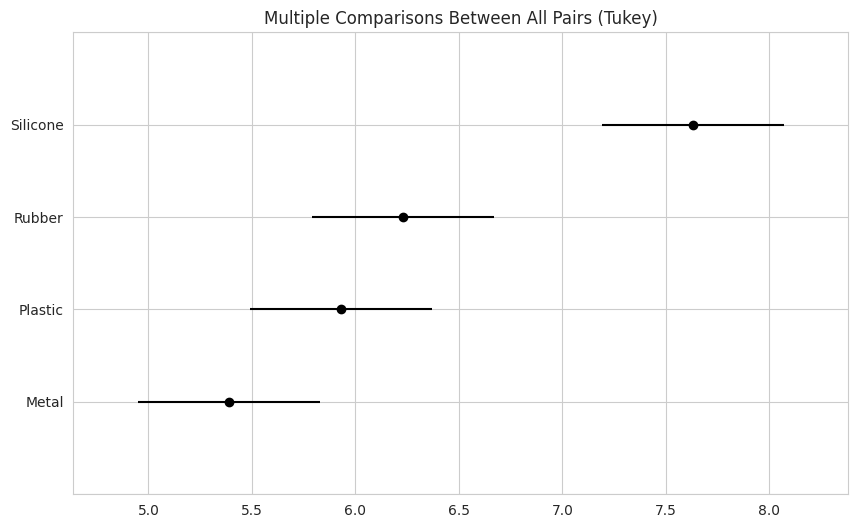

In [6]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test ##
tukey_result = pairwise_tukeyhsd(endog=controller_data['Comfort'], groups=controller_data['Material'],
                                 alpha=0.05)

## Print Tukey Visualization ##
tukey_result.plot_simultaneous()

## Print Tukey Table ##
print(tukey_result)

The Tukey's HSD post-hoc test results show that Silicone differs significantly from all other material types. Specifically, Silicone had significantly higher mean comfort ratings than Metal (p < 0.001), Plastic (p < 0.001), and Rubber (p = 0.0007).

No statistically significant differences were found among Metal, Plastic, and Rubber.

Therefore, the main treatment differences appear to be driven by the Silicone grip material, which was rated significantly more comfortable than the other three materials.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, include potential limitations of this experiment and suggestions for future experimentation.

**Answer:** In this experiment, we investigated whether perceived comfort level differs across controller grips made from four different material types: **plastic, rubber, silicone, and metal**. The exploratory analysis showed that **Silicone** had the highest mean comfort rating, while **Metal** had the lowest.

The assumptions of **normality** and **homogeneity of variance** were both reasonably supported based on the diagnostic plots and formal tests. The one-way ANOVA indicated a **statistically significant treatment effect** ($F_{\text{Stat}} = 17.07$, $p < 0.001$), suggesting that mean comfort ratings were not equal across all four material types.

Tukey's HSD test further showed that **Silicone** had a significantly higher mean comfort rating than **Metal, Plastic, and Rubber**, while the differences among **Metal, Plastic, and Rubber** were not statistically significant.

One limitation of this experiment is that perceived comfort is a **subjective rating**, which may vary across individuals. In addition, all participants were **professional gamers playing the same game**, so the results may not generalize to casual players or other gaming contexts.

For future experimentation, it may be useful to include a **more diverse group of players**, test the controllers across **different game genres**, and examine additional factors such as **controller shape, grip texture, or long-term durability**.


**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Answer:** The objective of this experiment is to compare the mean quiz scores between the two class session methods, VR and Traditional, while controlling for prior working experience with elderly people. In this way, we can gather evidence on the effectiveness of the VR-based session while accounting for the potential confounding effect of prior experience.

**Question 2.** Specify the outcome variable

**Answer:** The outcome variable is the score on the 50-question quiz measuring attitudes toward elderly people, which is a quantitative, discrete variable.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

**Answer:**
- **IV:** Class session method used to train the nursing students which is nominal, categorical variable with 2 levels (Traditional, VR).
- **Blocking Factor:** Prior Experience is a nominal, categorical variable with two levels (Prior Experience, No Prior Experience).
- **Possible Lurking Variables:** Student motivation or interest in working with elderly people, instructor effectiveness, familiarity with VR technology, and mode or environment of quiz (in-person, online, etc.).

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

**Answer:** The students involved in the experiment (experimental units) have different levels of prior experience (blocking factor), this means our experimental units are not homogeneous with respect to prior experience of working with elderly people. Randomized block design is a type of experimental design that is used when the experimental units are not homogeneous with respect to a particular variable. It allows us to control for the potential confounding effect of prior working experience with elderly people on quiz scores. By blocking on prior experience, we can ensure that the VR and Traditional class session methods are fairly compared within each level of prior experience. This is why RBD is most suitable for this study.

For CRD, the experimental units should be homogeneous, which is not the case here. Due to this CRD is not suitable for this study.

**Question 5.** State the null and alternative hypotheses for this experiment.

**Answer:**
$$ \begin{align}
H_0&: \mu_{\text{Traditional}} = \mu_{\text{VR}} \\
H_1&: \mu_{\text{Traditional}} \neq \mu_{\text{VR}}
\end{align}
$$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Answer:**


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Method      40 non-null     object
 1   Experience  40 non-null     object
 2   Score       40 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB
None
                                 mean       std
Experience          Method                     
No Prior Experience Traditional  30.7  4.691600
                    VR           37.3  7.916930
Prior Experience    Traditional  30.9  8.556349
                    VR           39.7  6.056218


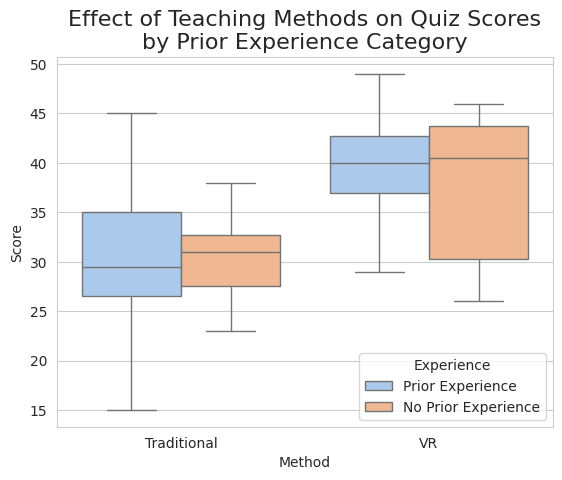

In [5]:
## Import Appropriate Libraries ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Import Data ##
teaching = pd.read_excel('Nursing VR Study.xlsx')

## Data Integrity Check ##
print(teaching.info())

## Calculate Means and Standard Deviations
## by Prior Knowledge and Teaching Method ##
sum_stats = teaching.groupby(['Experience','Method'])['Score'].agg(['mean','std'])

print(sum_stats)

## Create the boxplot using seaborn.
sns.set_style("whitegrid")

sns.boxplot(
    data=teaching,
    x='Method',
    y='Score',
    hue='Experience',
    palette='pastel'
)

## Add labels and titles ##
plt.title("Effect of Teaching Methods on Quiz Scores\nby Prior Experience Category",
          loc='center',
          fontsize=16)

## Show the plot ##
plt.show()

Based on the summary statistics, the VR teaching method has a higher mean quiz score than the Traditional method within both prior experience groups. For students with no prior experience, the means are 37.3 (VR) versus 30.7 (Traditional), and for students with prior experience, the means are 39.7 (VR) versus 30.9 (Traditional).

The boxplot supports this pattern, as the VR groups are centered above the Traditional groups in both blocks, although some overlap is present.

Thus, the exploratory analyses lend stronger support to the **alternative hypothesis**, since the treatment means do not appear to be equal and the VR method seems to perform better overall.

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Answer:**

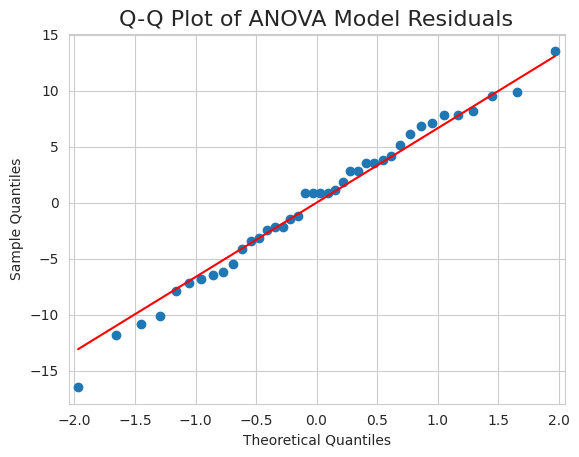

Shapiro-Wilk Test Statistic: 0.9869
Shapiro-Wilk Test P-Value: 0.9173
The residuals are normally distributed (fail to reject H0).


In [6]:
## Assessing Normality ##

## Import scipy ##
import scipy.stats as stats

## Fit model ##
ex_mod = ols("Score~Method+Experience",data=teaching).fit()

## Extract Model Residuals ##
ex_residuals = ex_mod.resid

## Generate QQ plot using seaborn ##
sm.qqplot(ex_residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals", fontsize=16)
plt.show()

## Perform Shapiro-Wilk Test ##
shapiro_test = stats.shapiro(ex_residuals)
## Get Test Stat ##
shapiro_stat = shapiro_test.statistic
## Get P-Value ##
shapiro_pvalue = shapiro_test.pvalue
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {shapiro_pvalue:.4f}")
if shapiro_pvalue < 0.05:
    print("The residuals are not normally distributed (reject H0).")
else:
    print("The residuals are normally distributed (fail to reject H0).")

From the QQ plot, the residuals appear to follow the reference line fairly closely, with only minor deviations near the ends, suggesting no serious violation of normality.

The Shapiro–Wilk test gave a statistic of ($W=0.9869$) and a p-value ($p=0.9173$). Since $p > \alpha = 0.05$, we fail to reject the null hypothesis that the residuals are normally distributed.

Therefore, the results of both the visual and formal normality checks support the assumption of normality.

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Answer:**

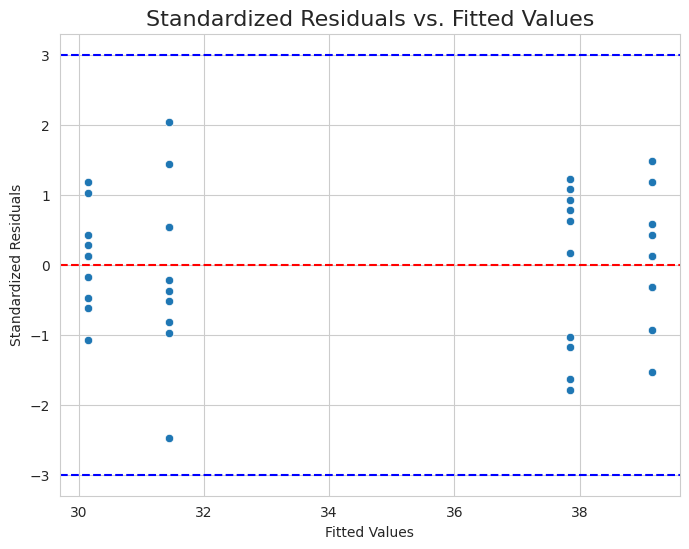

F-statistic: 0.19858503981404418
F p-value: 0.8207581702983743
No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.


In [7]:
## Constant Variance Check ##

## Scatterplot of Standardized Residuals to Fitted Values ##
## Obtain Standardized Residuals ##
standardized_residuals = ex_mod.get_influence().resid_studentized_internal

## Get the fitted values ##
fitted_values = ex_mod.fittedvalues

## Create the plot using seaborn ##
plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values", fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## B-P Test ##
## Import necessary function: ##
from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##
bp_test = het_breuschpagan(ex_mod.resid,ex_mod.model.exog)

## Extract F-statistic ##
f_statistic = bp_test[2]

## Extract its P-Value ##
f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0). Constant Variance not assumed.")
else:
    print("No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.")

From the residual plot:
- The points appear randomly scattered around 0 with a fairly similar vertical spread across fitted values.
- There is no clear pattern suggesting changing variance.
- All standardized residuals fall within the $\pm$3 reference lines.

The Breusch-Pagan test gave an F-statistic of 0.1986 and a p-value of 0.8207. Since $p > \alpha = 0.05$, we fail to reject the null hypothesis of constant variance.

Therefore, both the visual and formal methods support the assumption of homogeneity of variance.

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Answer:**

In [9]:
## Obtain ANOVA Table ##

## Note, we use Type III SS so that way the Teaching Treatment
## is evaluated after adjusting for Prior Experience Category ##
ex_tab = sm.stats.anova_lm(ex_mod,typ=3)

## Add Significance Column ##
ex_tab["Significance"] = np.where(ex_tab["PR(>F)"]<0.05,"Significant","Not Significant")

## Print ANOVA Table Result ##
print(ex_tab)

             sum_sq    df           F        PR(>F)     Significance
Intercept   12120.3   1.0  254.324902  3.660493e-18      Significant
Method        592.9   1.0   12.441048  1.140403e-03      Significant
Experience     16.9   1.0    0.354619  5.551352e-01  Not Significant
Residual     1763.3  37.0         NaN           NaN  Not Significant


- Our $F_{\text{Stat}} = F(1, 37) = 12.44$ and has an associated p-value $p = 0.0011$.

- This indicates that our data more strongly support the **alternative hypothesis**, if we use our traditional $\alpha$-level of 0.05.

- In context, this suggests that, after adjusting for prior experience, the mean quiz scores differ between the VR and Traditional teaching methods.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Answer:**

Figure(1000x600)
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
   group1   group2 meandiff p-adj lower   upper  reject
-------------------------------------------------------
Traditional     VR      7.7 0.001 3.3184 12.0816   True
-------------------------------------------------------


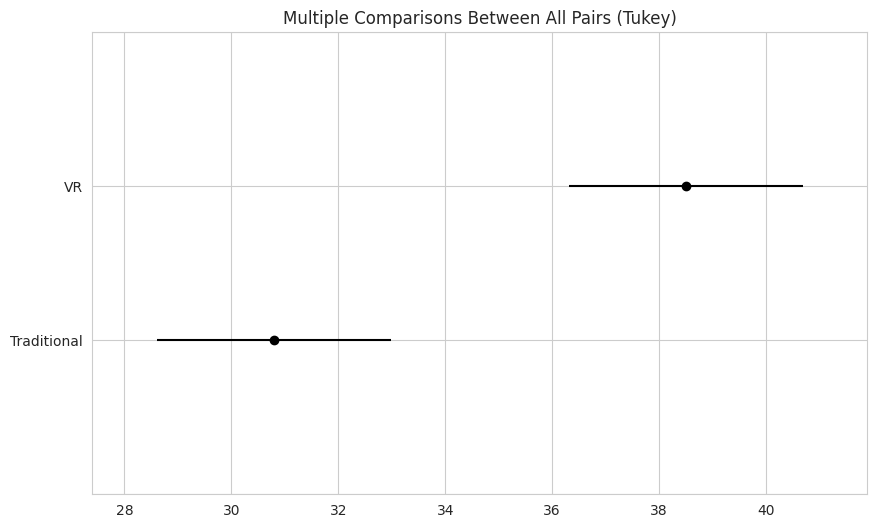

In [10]:
## Import pairwise_tukeyhsd function ##
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test ##
tukey_result = pairwise_tukeyhsd(endog=teaching['Score'], groups=teaching['Method'],
                                 alpha=0.05)

## Print Tukey Visualization ##
print(tukey_result.plot_simultaneous())

print(tukey_result)

Because the data more strongly supported the alternative hypothesis, we performed the Tukey's HSD test. The test showed a statistically significant difference between the Traditional and VR methods (mean difference = 7.7, $p$ = 0.001), with the VR group having the higher mean quiz score. Since there are only two treatment levels, this post-hoc test simply confirms the ANOVA result.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment and suggestions for future experimentation.

**Answer:** In this experiment, we investigated whether a **VR-based class session** and a **traditional class session** differ in their effect on undergraduate nursing students' attitudes toward elderly people, while controlling for **prior working experience with elderly people**. The exploratory analysis suggested that the **VR** method produced higher mean quiz scores than the **Traditional** method within both prior experience groups. The assumptions of **normality** and **homogeneity of variance** were both reasonably supported based on the diagnostic plots and formal tests. The two-way ANOVA indicated a **statistically significant treatment effect** for **Method** ($F(1,37)=12.44, p=0.0011$), suggesting that mean quiz scores differ between the two teaching methods after adjusting for prior experience. Tukey's HSD test further confirmed that the **VR** group had a significantly higher mean quiz score than the **Traditional** group, with a mean difference of **7.7 points**.

One limitation of this experiment is that the outcome was based on a **single quiz administered immediately after the class session**, so it may not fully reflect long-term attitudes or real-world behavior when working with elderly patients. In addition, the sample included only **undergraduate nursing students**, which may limit how well the results generalize to other student populations or healthcare trainees.

For future experimentation, it may be useful to include a **larger and more diverse sample**, measure outcomes over a **longer follow-up period**, and examine whether the VR training improves not only quiz performance but also **practical communication and caregiving skills** in realistic healthcare settings.


**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

**Answer:** A one-factor completely randomized design (CRD) would not generally be ideal for studies involving human participants because people are often not homogeneous experimental units. Humans can differ in many important ways, such as different demographics, prior experience or knowledge, health status, motivation, background, or ability level, and these differences can affect the response variable. If those sources of variability are ignored and participants are only randomly assigned to treatment groups, then treatment comparisons may be confounded. In human studies, it is often better to use designs such as randomized block designs (RBD) or other controlled approaches that account for important participant differences.

**Question 2.** What is the purpose of post-hoc tests?

**Answer:** The purpose of post-hoc tests is to determine which specific group means differ from each other after an omnibus ANOVA test has found a statistically significant difference. The ANOVA tells us that not all means are equal, but it does not tell us exactly where those differences occur. Post-hoc tests, such as Tukey's HSD, allow us to make pairwise comparisons between treatment groups while controlling for the increased risk of Type I error rate by maintaining the desired overall significance level, $\alpha$, that comes from making multiple comparisons.

**Question 3.** Explain the difference between RBD and LSD.

**Answer:** The main difference between RBD and LSD is the number of nuisance variables they are designed to control.

- A RBD is used when there is **one important blocking factor** that may affect the response variable. The experimental units are grouped into blocks based on that one variable, and treatments are then randomly assigned within each block. The goal is to reduce variability due to that single nuisance factor.

- A LSD is used when there are **two blocking factors** that may influence the response. In this design, treatments are arranged in a square so that each treatment appears **exactly once in each row and exactly once in each column**. This allows the experimenter to control for two nuisance variables at the same time.

**Question 4.** Explain why randomization is important in designing experiments.

**Answer:** Randomization is important in designing experiments because it helps create comparable treatment groups. By randomly assigning experimental units to treatments, we reduce the chance that other uncontrolled variables favor one treatment over another. This helps minimize bias, balance out lurking variables on average, and ensure that the conclusions we draw are accurate to the treatment effect rather than to confounding factors.

**Question 5.** Explain why replication is important in designing experiments.

**Answer:** Replication is important in designing experiments because it provides more than one experimental unit per treatment group. This is important for two main reasons:
1. Without replication, we would not be able to tell whether observed treatment differences are truly due to the treatment or just a random result of the specific experimental units used in the study.
2. Replication allows us to estimate the variability within treatment groups. Without that variation, statistical procedures such as ANOVA and hypothesis tests would not work properly.

Replication also improves the reliability and precision of the conclusions.